## Carga de datos y librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:

gym_churn_us= pd.read_csv('/datasets/gym_churn_us.csv')
gym_churn_us.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
gym_churn_us.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [4]:
print(gym_churn_us.columns) 

Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime',
       'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
       'Churn'],
      dtype='object')


Para el desarrollo de este proyecto, se utilizaron archivos en formato CSV proporcionados por Model Fitness, los cuales contienen información sobre la cancelación de clientes en un mes específico y datos correspondientes al mes anterior.

El conjunto de datos incluye la variable Churn, que indica si un cliente canceló su suscripción, así como información actual y datos históricos de los usuarios. Estos datos permiten analizar el comportamiento de los clientes, identificar patrones asociados a la cancelación y construir modelos predictivos.

La descarga de estos archivos es fundamental para realizar el análisis exploratorio, el procesamiento de la información y el entrenamiento de modelos, con el fin de apoyar la toma de decisiones y proponer estrategias de retención.

## Analisis Exploratorios

Observa el dataset: ¿contiene alguna característica ausente? Estudia los valores promedio y la desviación estándar (utiliza el método describe()).
Observa los valores medios de las características en dos grupos: para las personas que se fueron (cancelación) y para las que se quedaron (utiliza el método groupby()).
Traza histogramas de barras y distribuciones de características para aquellas personas que se fueron (cancelación) y para las que se quedaron.
Crea una matriz de correlación y muéstrala.

In [5]:
gym_churn_us.isnull().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

In [6]:
gym_churn_us.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [7]:
gym_churn_us.groupby('Churn').mean(numeric_only=True)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


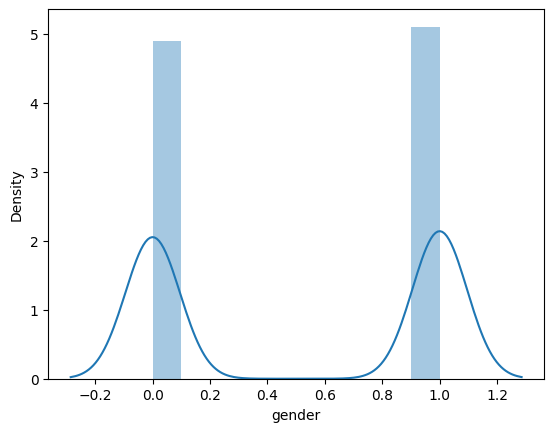

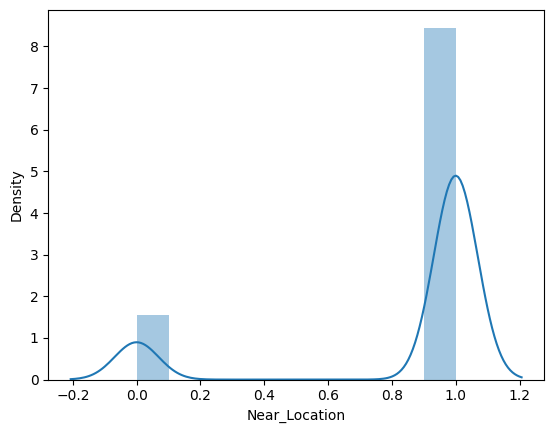

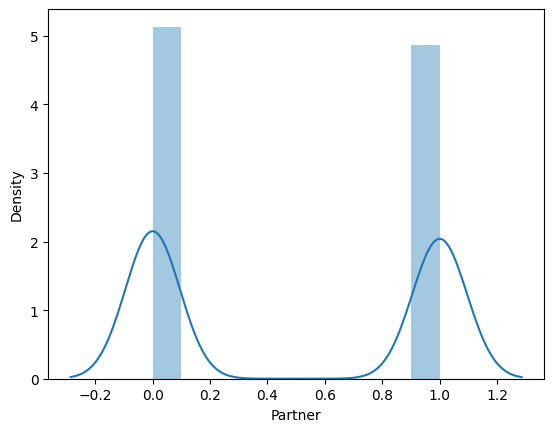

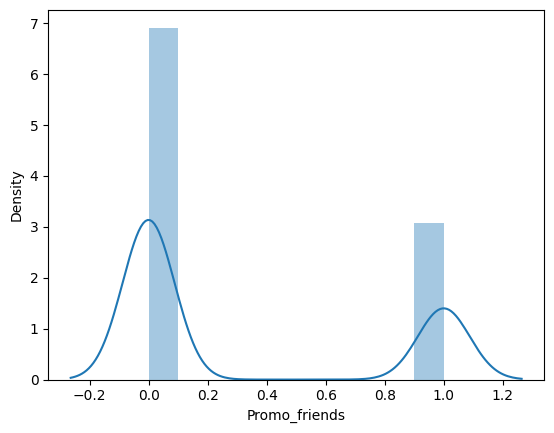

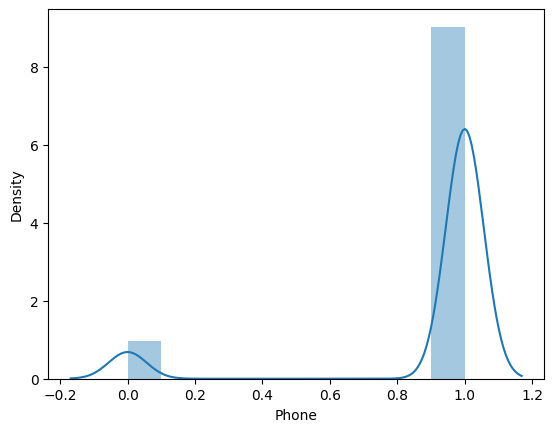

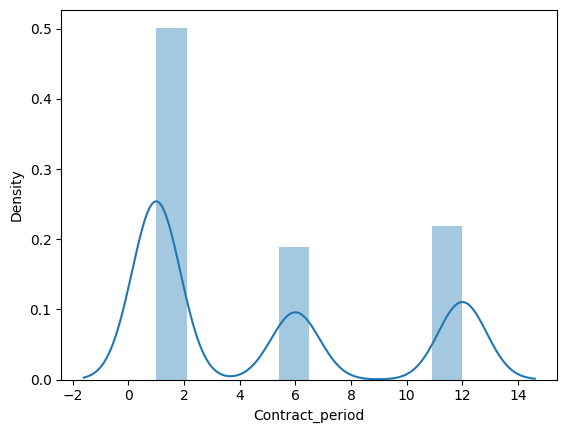

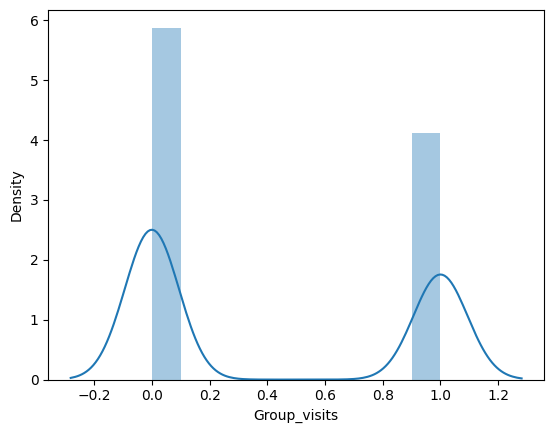

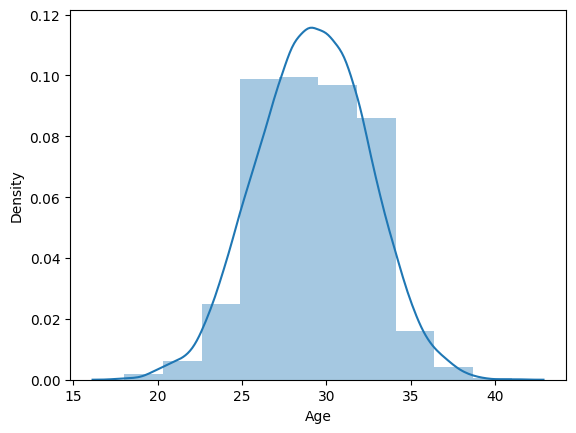

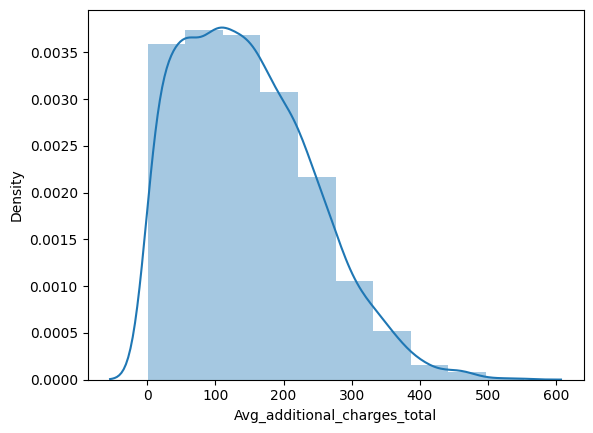

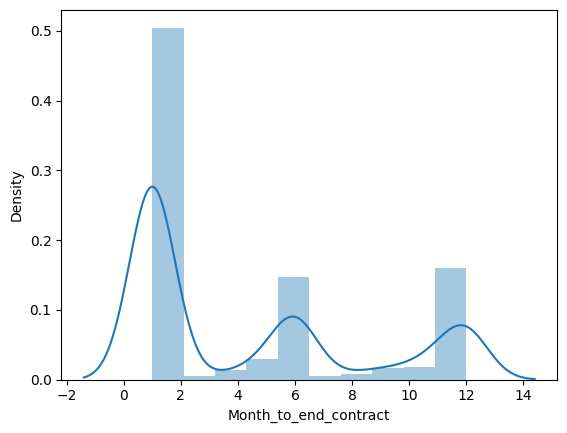

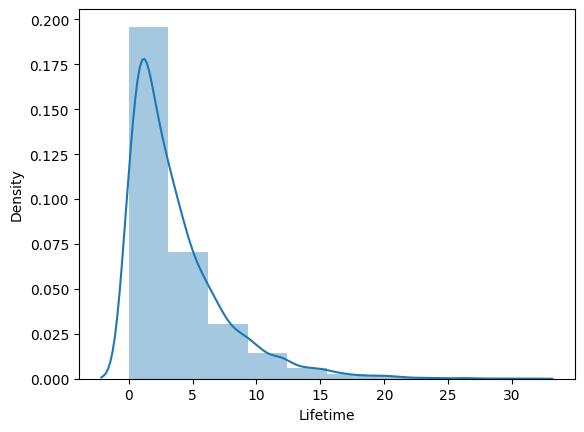

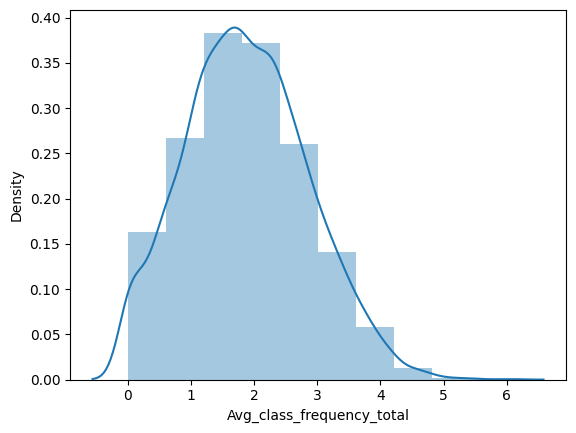

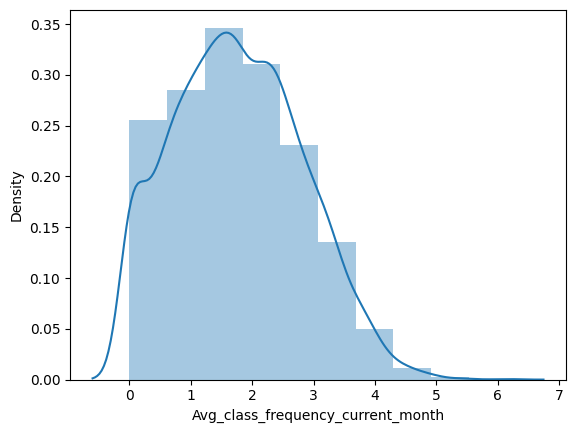

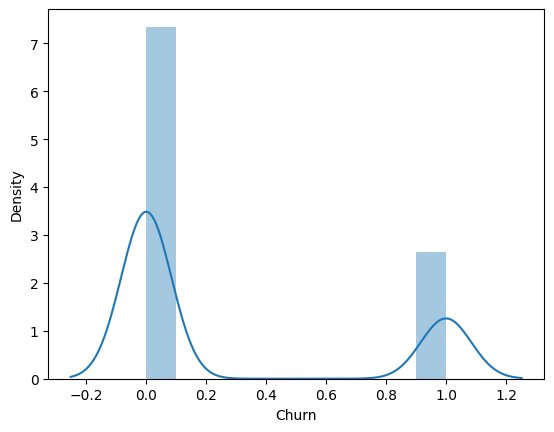

In [8]:
for feature in gym_churn_us.columns:
  sns.distplot(gym_churn_us[feature], bins = 10)
  plt.show()

## Construir un modelo para predecir la cancelación de usuarios

In [9]:
gym_churn_us.corr()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
Near_Location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
Partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
Promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
Phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
Contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
Group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
Age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
Avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
Month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


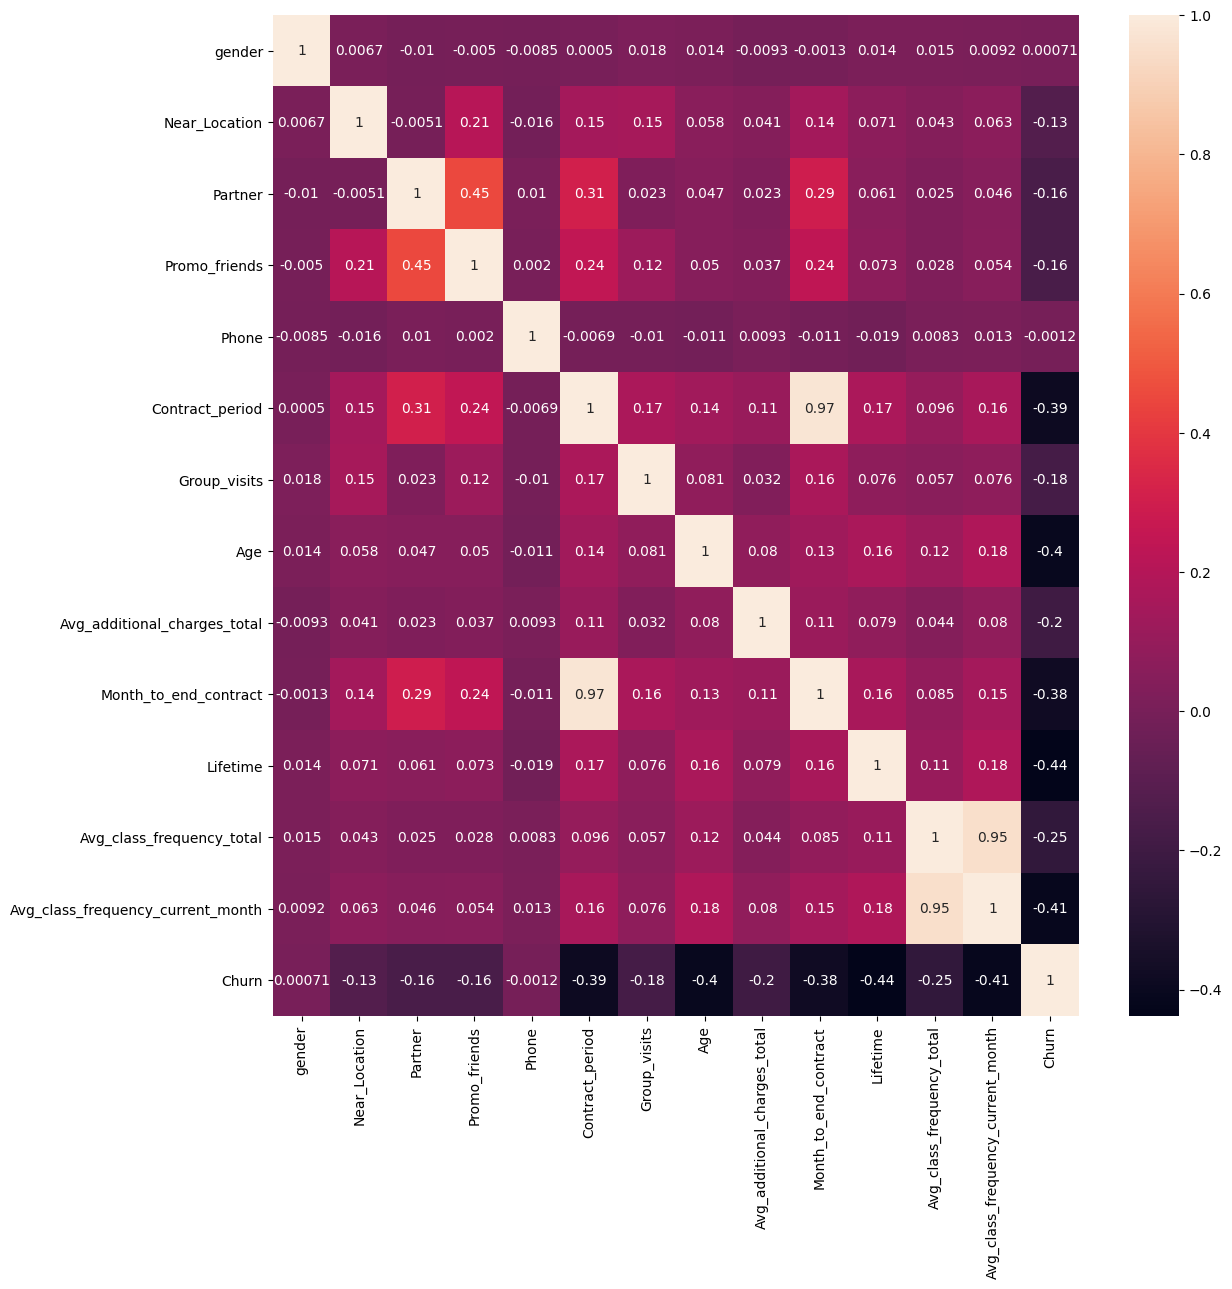

In [10]:


plt.figure(figsize=(13,13))
sns.heatmap(gym_churn_us.corr(), annot=True)
plt.show()

La matriz de correlación muestra que la cancelación está relacionada principalmente con la frecuencia de asistencia, la duración del contrato y la antigüedad del cliente. Asimismo, se observan relaciones entre algunas variables, aunque sin evidenciar multicolinealidad severa. Esto permitió seleccionar y mantener características relevantes para el modelado.

Crea un modelo de clasificación binaria para clientes donde la característica objetivo es la marcha del usuario o la usuaria el mes siguiente.

Divide los datos en conjuntos de entrenamiento y validación utilizando la función train_test_split().
Entrena el modelo en el set de entrenamiento con dos métodos:
regresión logística;
bosque aleatorio.
Evalúa la exactitud, precisión y recall para ambos modelos utilizando los datos de validación. Utilízalos para comparar los modelos. ¿Qué modelo dio mejores resultados?
Recuerda indicar el parámetro random_state cuando dividas los datos y definas el algoritmo. 

In [11]:
# mira la relación entre las clases del dataset
gym_churn_us['Churn'].value_counts()

0    2939
1    1061
Name: Churn, dtype: int64

In [12]:
X = gym_churn_us.drop('Churn', axis=1)
y = gym_churn_us['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

In [13]:
lr_model = LogisticRegression(max_iter=500)

In [14]:
lr_model.fit(X_train_st, y_train)

LogisticRegression(max_iter=500)

In [15]:
# definir el algoritmo del nuevo modelo basándose en el algoritmo de bosque aleatorio
lr_model = RandomForestRegressor(n_estimators=100, random_state=42)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
y_pred = (y_pred >= 0.5).astype(int)

In [16]:
acc = accuracy_score(y_test, y_pred)
precision = precision_score (y_test, y_pred)
recall = recall_score (y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

print(f"Accuracy: {acc:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

Accuracy: 0.93
Precision: 0.89
Recall: 0.82
F1 Score: 0.85
Accuracy: 0.93, Precision: 0.89, Recall: 0.82, F1: 0.85


## . Crear clústeres de usuarios/as

Deja de lado la columna con datos sobre la cancelación e identifica los clústeres de objetos (usuarios/as):

Estandariza los datos.
Utiliza la función linkage() para crear una matriz de distancias basada en la matriz de características estandarizada y trazar un dendrograma. Nota: ¡renderizar el dendrograma puede llevar tiempo! Utiliza el gráfico resultante para estimar el número de clústeres que puedes destacar.
Entrena el modelo de clustering con el algortimo K-means y predice los clústeres de clientes. (Deja que el número de clústeres sea n=5 para que sea más sencillo comparar los resultados con los del resto del estudiantado. Sin embargo, en la vida real, nadie te dará tales pistas, así que tendrás que decidir basándote en el gráfico del paso anterior.)
Mira los valores medios de característica para los clústeres.¿Hay algo que te llame la atención?
Traza distribuciones de características para los clústeres. ¿Notas algo?
Calcula la tasa de cancelación para cada clúster (utiliza el método groupby()). ¿Difieren en términos de tasa de cancelación? ¿Qué grupos son propensos a irse y cuáles son leales?

In [17]:
X = gym_churn_us.drop(columns=['Churn'])

sc = StandardScaler()
x_sc = sc.fit_transform(X)


In [18]:
linked = linkage(x_sc, method = 'ward')

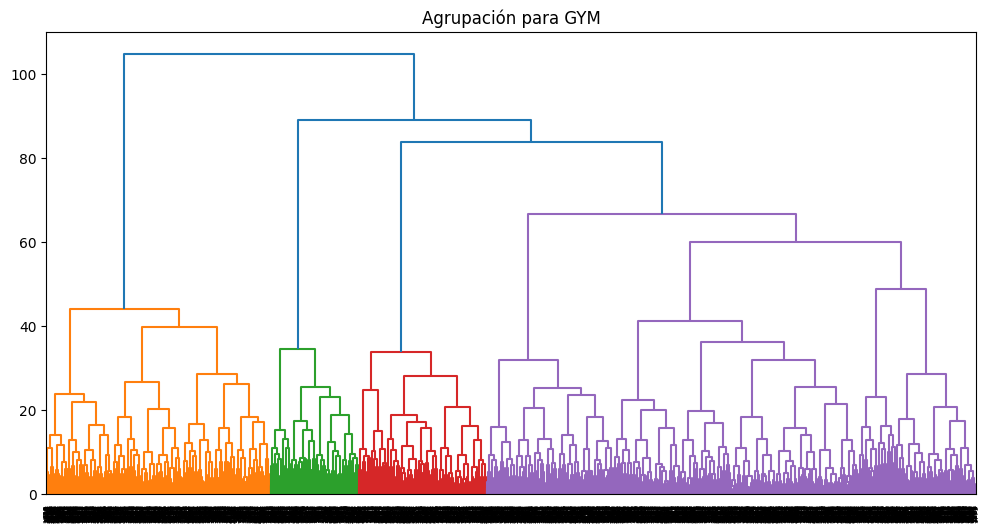

In [19]:
plt.figure(figsize=(12, 6))  
dendrogram(linked, orientation='top')
plt.title('Agrupación para GYM')
plt.show()

In [20]:
km = KMeans(n_clusters=5, random_state=42)
labels = km.fit_predict(x_sc)
X['cluster_km'] = labels
gym_churn_us['cluster'] = labels
print(gym_churn_us.head())

   gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   Group_visits  Age  Avg_additional_charges_total  Month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_month  \
0  

In [21]:
gym_churn_us

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,cluster
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0,4
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0,2
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0,3
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0,2
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0,2
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1,3
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0,2
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0,0


In [22]:
cluster_means = gym_churn_us.groupby('Churn').mean()
cluster_means

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,cluster
Churn,,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882,1.771011
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546,2.487276


In [ ]:
gym_churn_us.plot(kind='bar')
plt.title('Tasa de cancelación por cluster')
plt.ylabel('Group_visits')
plt.xlabel('Cluster')
plt.show()

## Conclusiones

Conclusiones y recomendaciones

A partir del análisis de segmentación y del modelo de predicción de cancelación, se pueden extraer las siguientes conclusiones:

Existen grupos de clientes con mayor riesgo de cancelación.
Algunos clústeres presentan una tasa de churn más alta, lo que indica baja fidelización y menor compromiso con el servicio.

La frecuencia de uso influye en la permanencia.
Los clientes que asisten con mayor regularidad tienden a permanecer más tiempo en el gimnasio.

El tipo de contrato afecta la retención.
Los usuarios con contratos más largos suelen ser más leales que quienes tienen contratos mensuales.

La antigüedad del cliente es un factor clave.
Los clientes nuevos tienen mayor probabilidad de abandonar en los primeros meses.

## Recomendaciones


In [ ]:
Recomendaciones

Con base en los resultados, se proponen las siguientes estrategias:

Programas de fidelización para clientes en riesgo

Enviar promociones personalizadas.

Ofrecer descuentos por renovación.

Contactar a clientes con baja asistencia.

Incentivar el uso frecuente del servicio

Bonos por asistencia.

Retos mensuales.

Clases grupales gratuitas.

Promover contratos de largo plazo

Descuentos por planes semestrales o anuales.

Beneficios exclusivos para planes largos.

Seguimiento a clientes nuevos

Llamadas de bienvenida.

Acompañamiento inicial.

Rutinas personalizadas.